In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.ndimage import binary_closing
from matplotlib.collections import LineCollection
from cleaning_pipeline_functions import *

In [4]:
# Data 
data = np.load('/home/hck03/Documents/MS_thesis/tracking_output/1c_4n_faulty/Clip0070_1C_4N_E3_8/data/grand_array.npy')
no_of_fishes = data.shape[0]
no_of_frames = data.shape[1]
data[np.isinf(data)] = np.nan

vel_x = np.gradient(data[:,:,0], axis=1)
vel_y = np.gradient(data[:,:,1], axis=1)

vel = np.zeros((no_of_fishes, no_of_frames, 2))
vel[:, :, 0] = vel_x
vel[:, :, 1] = vel_y

speed = np.linalg.norm(vel, axis=2, ord=2)
acc_x = np.gradient(vel_x, axis=1)
acc_y = np.gradient(vel_y, axis=1)
acc_vec = np.zeros(data.shape)
acc_vec[:, :, 0] = acc_x
acc_vec[:, :, 1] = acc_y
acceleration = np.linalg.norm(acc_vec, ord=2, axis=2)
accel_threshold = 0.3

In [5]:
# Functions
def hiccups(speed):
    speed_spikes = []
    speed_threshold = np.nanpercentile(speed, 95)

    for i in range(1, no_of_frames-1):
        incoming_speed = abs(speed[i-1])
        current_speed = abs(speed[i])
        outgoing_speed = abs(speed[i+1])
        if current_speed > speed_threshold and incoming_speed < speed_threshold and outgoing_speed < speed_threshold:
            speed_spikes.append(i)
    return speed_spikes

def large_jumps(acceleration):
    spike_mask = np.abs(acceleration) > accel_threshold

    max_gap_frames = 10
    grouped_mask = binary_closing(spike_mask, structure=np.ones(max_gap_frames))

    padded_mask = np.pad(grouped_mask, (1, 1), mode='constant', constant_values=False)
    transitions = np.diff(padded_mask.astype(int))

    start_indices = np.where(transitions == 1)[0]
    end_indices = np.where(transitions == -1)[0] - 1

    jump_regions = list(zip(start_indices, end_indices))
    lists_of_jumps = [list(range(jump_regions[i][0], jump_regions[i][1]+1)) for i in range(len(jump_regions))]
    big_jump_indicies = list({indices for sublist in lists_of_jumps for indices in sublist})
    return jump_regions, big_jump_indicies

# def path_straightness(x, y, i, j):
#     if j <= i:
#         return 1.0
#     net_disp = np.hypot(x[j] - x[i], y[j] - y[i])
#     path_len = np.nansum(np.hypot(np.diff(x[i:j + 1]), np.diff(y[i:j + 1])))
#     return 1.0 if path_len == 0 else net_disp / path_len


# def large_jumps(x, y, spike_mask, max_gap_frames=15, straightness_threshold=0.5, tight_gap=3):
#     grouped = binary_closing(spike_mask, structure=np.ones(tight_gap), border_value=1)

#     padded = np.pad(grouped, (1, 1), mode='constant', constant_values=False)
#     transitions = np.diff(padded.astype(int))
#     starts = np.where(transitions == 1)[0]
#     ends = np.where(transitions == -1)[0] - 1
#     regions = list(zip(starts.tolist(), ends.tolist()))

#     if not regions:
#         return [], []

#     merged = [regions[0]]
#     for region in regions[1:]:
#         gap_start, gap_end = merged[-1][1], region[0]
#         gap_len = gap_end - gap_start - 1
#         if gap_len <= max_gap_frames and path_straightness(x, y, gap_start, gap_end) < straightness_threshold:
#             merged[-1] = (merged[-1][0], region[1])   # tortuous gap -> bridge it
#         else:
#             merged.append(region)                      # direct gap -> leave frames alone

#     big_jump_indices = sorted({i for s, e in merged for i in range(s, e + 1)})
#     return merged, big_jump_indices

def angle_spikes(x,y):
    positions = np.vstack((x,y))
    positions = positions.T
    positions[np.isinf(positions)] = np.nan

    vec = np.diff(positions, axis=0)
    dot_prod_new = np.sum(vec[1:,:]*vec[:-1,:], axis=1)
    denominator = (np.linalg.norm(vec[1:, :], axis=1)*np.linalg.norm(vec[:-1,:], axis=1))
    safe_mask = (denominator > 0)
    cos_theta_new = np.zeros(dot_prod_new.shape[0])
    cos_theta_new[safe_mask] = dot_prod_new[safe_mask]/denominator[safe_mask]
    cos_theta_new = np.clip(cos_theta_new, -1.0, 1.0)

    angle_threshold = -0.5

    angle_spikes_mask = (cos_theta_new < angle_threshold)
    angle_spikes_new = np.arange(len(cos_theta_new))[angle_spikes_mask]
    return angle_spikes_new

def median_smoothener(k, x_clean, y_clean):
    k = 3  # window size
    x_smooth = x_clean.copy()
    y_smooth = y_clean.copy()

    for i in range(k, no_of_frames-k):
        window_start, window_end = i-int(np.floor(k/2)), i+int(np.floor(k/2))
        window_x = x_clean[window_start:window_end+1]
        window_y = y_clean[window_start:window_end+1]
        x_smooth[i] = np.median(window_x)
        y_smooth[i] = np.median(window_y)
    return x_smooth, y_smooth

In [6]:
# isolating also the problematic indices
# first we will remove all the speed spikes and the angular spikes
spike_mask = np.abs(acceleration) > accel_threshold
speed_spikes = []
angle_jumps = []
jump_regions, jump_indices = [], []

for i in range(no_of_fishes):
    x_i = data[i,:,0]
    y_i = data[i,:,1]
    speed_i = speed[i,:]
    speed_spikes_i = hiccups(speed_i)
    angle_spikes_i = angle_spikes(x_i, y_i)
    jump_regions_i, jump_indices_i = large_jumps(acceleration[i, :])

    speed_spikes.append(speed_spikes_i)
    angle_jumps.append(angle_spikes_i)
    jump_regions.append(jump_regions_i)
    jump_indices.append(jump_indices_i)

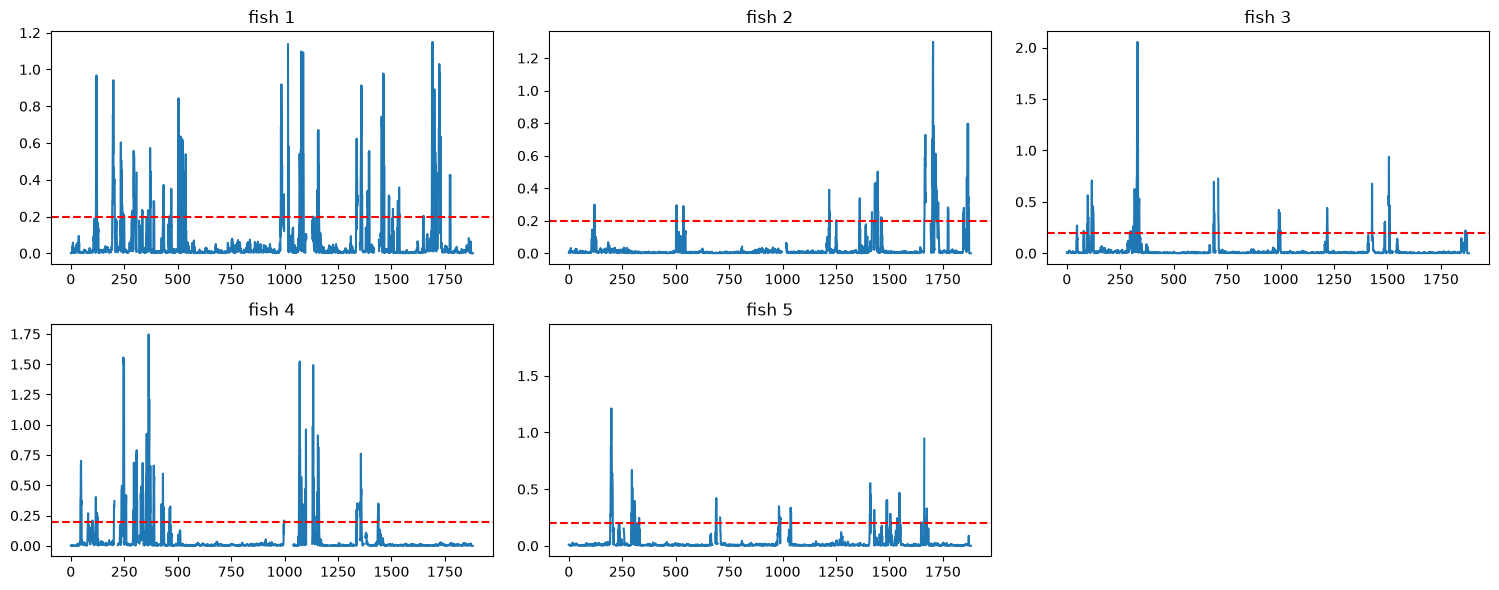

In [7]:
# plt.plot(range(len(acceleration)), abs(acceleration))
# plt.axhline(y=accel_threshold, linestyle='--', color='r')
# plt.show()
fig, ax = plt.subplots(2, 3, figsize=(15, 6))
flat_axes = ax.flatten()

fig.delaxes(flat_axes[5])
accel_thresholds = [0.2, 0.2, 0.2, 0.2, 0.2]
for i in range(no_of_fishes):
    acc_i = acceleration[i,:]
    flat_axes[i].plot(range(no_of_frames), acc_i)
    flat_axes[i].axhline(y=accel_thresholds[i], linestyle='--', color='r')
    flat_axes[i].set_title(f"fish {i+1}")
plt.tight_layout()

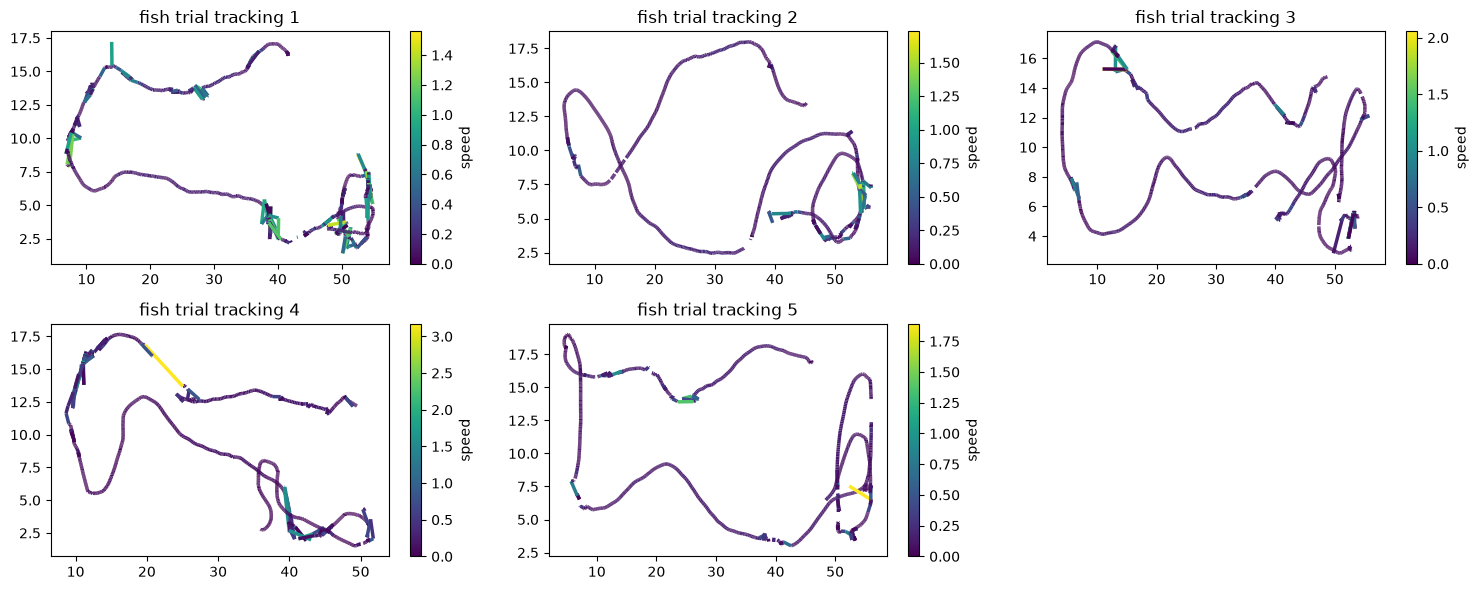

In [8]:
# raw trajectory with speed
fig, ax = plt.subplots(2, 3, figsize=(15, 6))
flat_axes = ax.flatten()

fig.delaxes(flat_axes[5])

for i in range(no_of_fishes):
    current_axis = flat_axes[i]
    time_steps = no_of_frames
    fish_x = data[i, :, 0]
    fish_y = data[i, :, 1]
    # fish_speeds = speed[i, :]
    speedy_trail(fish_x, fish_y, ax=current_axis, label=f"Fish {i+1}")
    current_axis.set_title(f"fish trial tracking {i+1}")

plt.tight_layout()
plt.show()

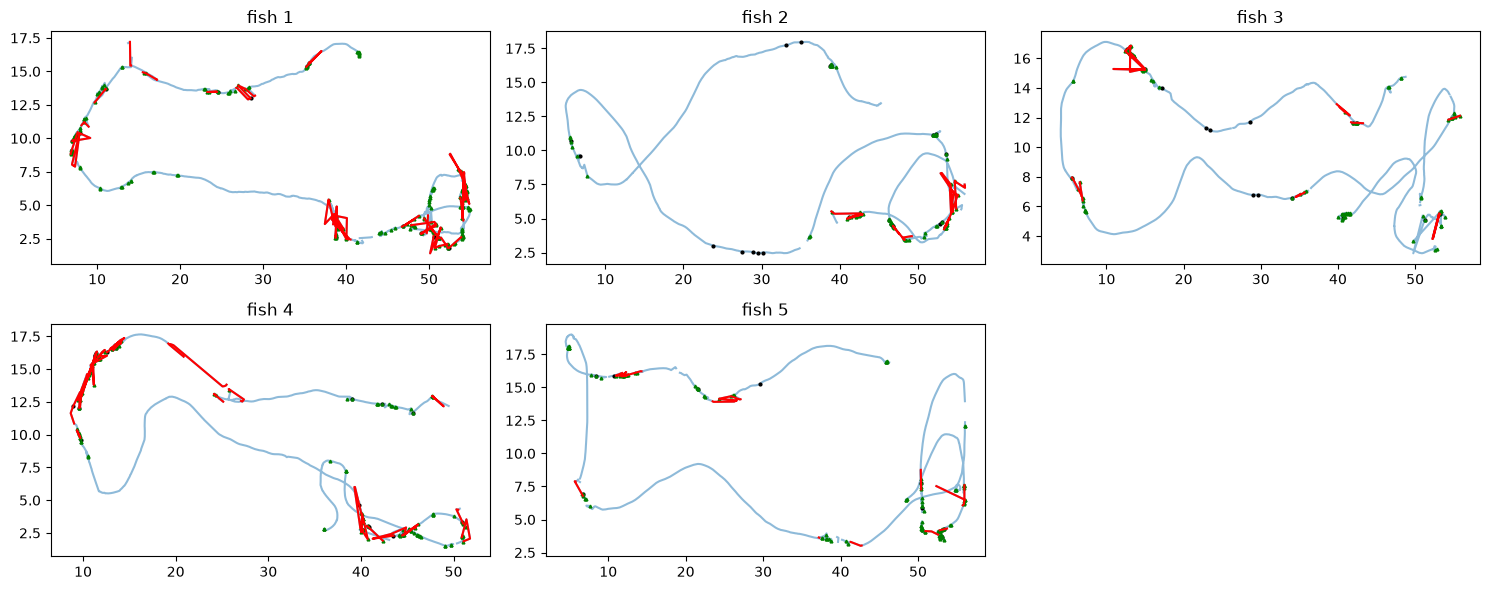

In [17]:
# trajectory with errors highlighted
# %matplotlib widget
# l = 10
# fig, ax = plt.subplots(figsize = (l, l*(20/50)))
# ax.plot(x, y, alpha=0.5)

# # speed spikes 
# for idx in speed_spikes:
#     ax.plot(x[idx], y[idx], 'ko', markersize=2)

# # angle jumps
# for j in angle_jumps:
#     ax.plot(x[j], y[j], color='green', marker='^', markersize=2)

# # big jumps
# for jump in jump_regions:
#     start_idx = jump[0]
#     end_idx = jump[1]
#     jump_traj_x = x[start_idx:end_idx+1]
#     jump_traj_y = y[start_idx:end_idx+1]
#     ax.plot(jump_traj_x, jump_traj_y, color='red')
fig, ax = plt.subplots(2, 3, figsize=(15, 6))
flat_axes = ax.flatten()

fig.delaxes(flat_axes[5])

for i in range(no_of_fishes):
    x_fish = data[i, :, 0]
    y_fish = data[i, :, 1]
    flat_axes[i].plot(x_fish, y_fish, alpha=0.5)
    fish_s_spikes = speed_spikes[i]
    fish_a_spikes = angle_jumps[i]
    fish_jump_region = jump_regions[i]
    for idx in fish_s_spikes:
        flat_axes[i].plot(x_fish[idx], y_fish[idx], 'ko', markersize=2)
    for j in fish_a_spikes:
        flat_axes[i].plot(x_fish[j], y_fish[j], color='green', marker='^', markersize=2)
    for jump in fish_jump_region:
        start_idx = jump[0]
        end_idx = jump[1]
        jump_traj_x = x_fish[start_idx:end_idx+1]
        jump_traj_y = y_fish[start_idx:end_idx+1]
        flat_axes[i].plot(jump_traj_x, jump_traj_y, color='red')
        flat_axes[i].set_title(f"fish {i+1}")
plt.tight_layout()

In [10]:
# visualizing jump regions
# jump_id = 9
# start, end = jump_regions[jump_id][0], jump_regions[jump_id][1]

# fig, ax = plt.subplots(1, 2, figsize=(10,4))

# ax[0].plot(x[start-100:end+100], y[start-100:end+100], alpha=0.5)
# ax[0].plot(x[start:end], y[start:end], color = 'red')
# ax[0].scatter(x[start:end], y[start:end], s=5)

# ax[1].plot(range(len(acceleration)), acceleration)
# ax[1].set_xlim(start-100, end+100)
# ax[1].axhline(y=accel_threshold, color='green', linestyle='--')
# ax[1].plot(range(start, end), acceleration[start:end], color='r')
# # ax[1].xticks(range(start, end), rotation=45)

In [11]:
data_clean = data.copy()

for i in range(no_of_fishes):
    clean_idx_i = list(set(speed_spikes[i])|set(angle_jumps[i])|set(jump_indices[i]))
    data_clean[i, clean_idx_i, :] = np.nan

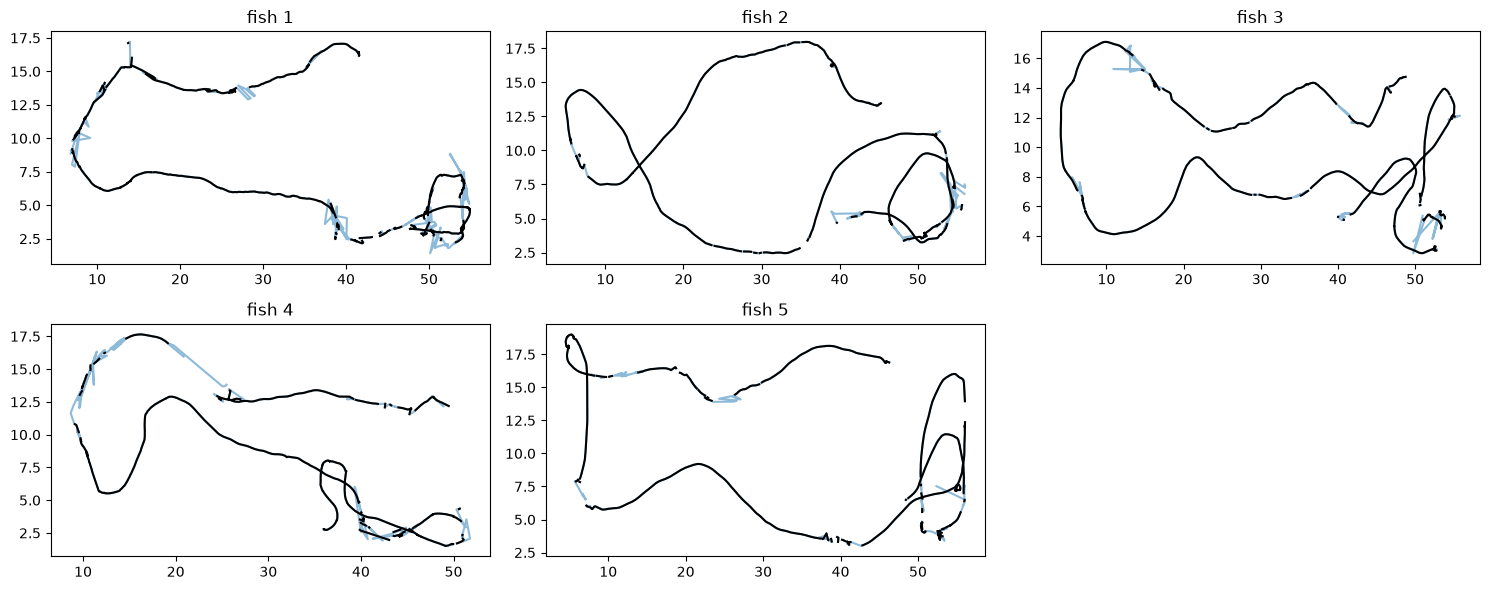

In [12]:
# clean trajectory
fig, ax = plt.subplots(2, 3, figsize=(15, 6))
flat_axes = ax.flatten()

fig.delaxes(flat_axes[5])

for i in range(no_of_fishes):
    x_i, y_i = data[i, :, 0], data[i, :, 1]
    x_clean_i, y_clean_i = data_clean[i, :, 0], data_clean[i, :, 1]
    flat_axes[i].plot(x_i, y_i, alpha=0.5)
    flat_axes[i].plot(x_clean_i, y_clean_i, 'k')
    flat_axes[i].set_title(f"fish {i+1}")
plt.tight_layout()

In [13]:
# median smoothened trajectory
# x_smooth, y_smooth = median_smoothener(k=3, x_clean=x_clean, y_clean=y_clean)
# l = 10
# fig, ax = plt.subplots(figsize = (l, l*(20/50)))
# ax.plot(x_smooth, y_smooth)

In [14]:
# smoothening without correction
# def mean_smoothener(k, x_clean, y_clea):
#     k = 3  # window size
#     x_smooth = x_clean.copy()
#     y_smooth = y_clean.copy()

#     for i in range(k, len(x[:-k])):
#         window_start, window_end = i-int(np.floor(k/2)), i+int(np.floor(k/2))
#         window_x = x_clean[window_start:window_end+1]
#         window_y = y_clean[window_start:window_end+1]
#         x_smooth[i] = np.mean(window_x)
#         y_smooth[i] = np.mean(window_y)
#     return x_smooth, y_smooth

# x_smooth_1, y_smooth_1 = mean_smoothener(k=10, x_clean=x, y_clean=y)
# l = 10
# fig, ax = plt.subplots(figsize = (l, l*(20/50)))
# # ax.plot(x_smooth_1, y_smooth_1)

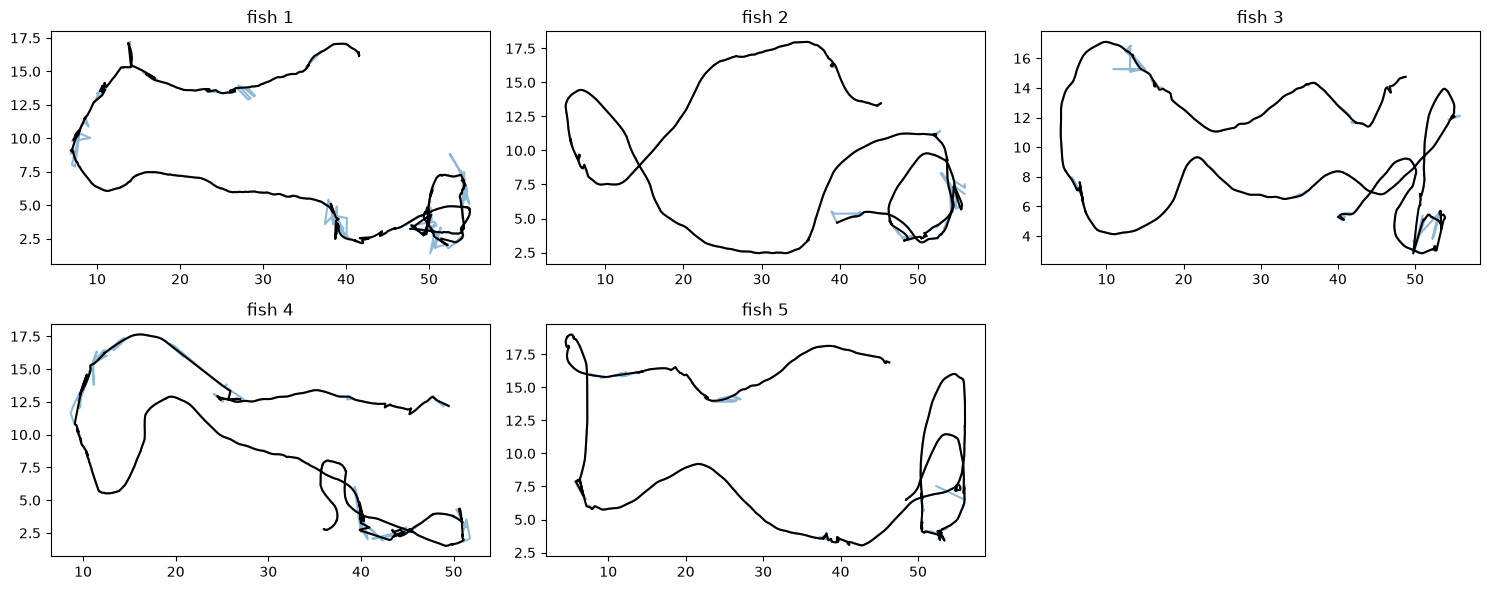

In [15]:
# Interpolated
fig, ax = plt.subplots(2, 3, figsize=(15, 6))
flat_axes = ax.flatten()

fig.delaxes(flat_axes[5])

for i in range(no_of_fishes):
    x_i, y_i = data[i, :, 0], data[i, :, 1]
    x_clean_i, y_clean_i = data_clean[i, :, 0], data_clean[i, :, 1]
    x_interp_i = pd.Series(x_clean_i).interpolate(method='pchip').to_numpy()
    y_interp_i = pd.Series(y_clean_i).interpolate(method='pchip').to_numpy()
    flat_axes[i].plot(x_i, y_i, alpha=0.5)
    flat_axes[i].plot(x_interp_i, y_interp_i, 'k')
    flat_axes[i].set_title(f"fish {i+1}")
plt.tight_layout()